# DDoS Detection using Machine Learning - SDN Ready

Notebook này là bản rút gọn, sạch và phù hợp để đưa vào báo cáo đồ án,
đồng thời xuất mô hình theo đúng định dạng để Ryu/SDN controller sử dụng.
Mục tiêu là xây dựng mô hình học máy phát hiện lưu lượng `Benign` và các
nhóm tấn công DDoS trong bộ dữ liệu CICDDoS2019.

Nguyên tắc chính:

- Không đưa nhãn mục tiêu vào tập đặc trưng.
- Không fit scaler, imputer hoặc bộ lọc tương quan trên toàn bộ dữ liệu trước khi chia train/test.
- Chia dữ liệu bằng `stratify` để giữ phân bố lớp.
- Đánh giá bằng các chỉ số phù hợp với dữ liệu mất cân bằng: `Balanced Accuracy`, `Macro F1`, `Weighted F1`, báo cáo từng lớp và ma trận nhầm lẫn.
- Lưu best pipeline trực tiếp vào `saved_models/selected_model.pkl` để controller có thể gọi `predict_proba`.

## 1. Project Overview

In [1]:
from pathlib import Path
import pickle
import re
import sys
import time
import warnings

candidate_roots = [
    Path.cwd(),
    Path.cwd().parent,
    Path(r"D:\source\CyRadar\VBoxShare\mlddos"),
    Path("/mnt/d/source/CyRadar/VBoxShare/mlddos"),
]
PROJECT_ROOT = next(
    (path for path in candidate_roots if (path / "backend" / "src").exists()),
    Path.cwd(),
)
BACKEND_SRC = PROJECT_ROOT / "backend" / "src"
if str(BACKEND_SRC) not in sys.path:
    sys.path.insert(0, str(BACKEND_SRC))

DATA_DIR = PROJECT_ROOT / "data"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "saved_models"
for directory in (DATA_DIR, RESULTS_DIR, MODELS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 3
CV_MAX_PER_CLASS = 3000

warnings.filterwarnings("ignore", category=FutureWarning)
print("Project root:", PROJECT_ROOT)
print("Dataset directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)

Project root: D:\source\CyRadar\VBoxShare\mlddos
Dataset directory: D:\source\CyRadar\VBoxShare\mlddos\data
Results directory: D:\source\CyRadar\VBoxShare\mlddos\results


## 2. Import Libraries

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns

from IPython import get_ipython
from IPython.display import display
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

from ml_ddos.data_loader import KAGGLE_DATASET_SLUG, collect_file_paths, load_dataset
from ml_ddos.models import (
    CappedUnderSamplingStrategy,
    LEAKAGE_COLUMN_PATTERNS,
    TrafficFeaturePreprocessor,
)
from ml_ddos.preprocessor import TARGET_COL, harmonize_labels, remove_duplicates
from ml_ddos.sdn_ryu_detector import CICDDOS_FEATURE_COLUMNS

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
print("Dataset:", KAGGLE_DATASET_SLUG)

Dataset: dhoogla/cicddos2019


## 3. Load Dataset

In [3]:
train_paths, test_paths = collect_file_paths(str(DATA_DIR))
file_summary = pd.DataFrame(
    {
        "training_files": pd.Series([Path(path).name for path in train_paths]),
        "testing_files": pd.Series([Path(path).name for path in test_paths]),
    }
)
display(file_summary.head(20))

train_raw, test_raw = load_dataset(str(DATA_DIR))
print("Raw train shape:", train_raw.shape)
print("Raw test shape:", test_raw.shape)
display(train_raw.head())
print("Columns:")
print(list(train_raw.columns))

if TARGET_COL not in train_raw.columns or TARGET_COL not in test_raw.columns:
    raise ValueError(f"Target column '{TARGET_COL}' not found in train/test data.")

[data_loader] Found 7 training files, 10 testing files.


,training_files,testing_files
0,LDAP-training.parquet,DNS-testing.parquet
1,MSSQL-training.parquet,LDAP-testing.parquet
2,NetBIOS-training.parquet,MSSQL-testing.parquet
3,Portmap-training.parquet,NTP-testing.parquet
4,Syn-training.parquet,NetBIOS-testing.parquet
5,UDP-training.parquet,SNMP-testing.parquet
6,UDPLag-training.parquet,Syn-testing.parquet
7,NaN,TFTP-testing.parquet
8,NaN,UDP-testing.parquet
9,NaN,UDPLag-testing.parquet


[data_loader] Dataset already present (17 files). Skipping download.
[data_loader] Found 7 training files, 10 testing files.
[data_loader] Common attack types: ['LDAP', 'MSSQL', 'NetBIOS', 'Syn', 'UDP', 'UDPLag']
[data_loader] Loading training data ...


Train files:   0%|          | 0/6 [00:00<?, ?it/s]

Train files:  83%|████████▎ | 5/6 [00:00<00:00, 45.68it/s]

...

Test files:   0%|          | 0/6 [00:00<?, ?it/s]

Test files: 100%|██████████| 6/6 [00:00<00:00, 101.75it/s]

[data_loader] Train shape: (120065, 78), Test shape: (38973, 78)
Raw train shape: (120065, 78)
Raw test shape: (38973, 78)


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,17,49,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
1,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,1480,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
2,17,1,2,0,458.0,0.0,229.0,229.0,229.0,0.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NetBIOS
3,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,14,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP
4,17,1,2,0,2944.0,0.0,1472.0,1472.0,1472.0,0.0,...,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,LDAP


Columns:
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'D

## 4. Data Cleaning

In [4]:
train_harmonized, test_harmonized = harmonize_labels(train_raw, test_raw)

cleaning_summary = pd.DataFrame(
    [
        {
            "split": "train",
            "rows_before": len(train_harmonized),
            "duplicates_before": int(train_harmonized.duplicated().sum()),
        },
        {
            "split": "test",
            "rows_before": len(test_harmonized),
            "duplicates_before": int(test_harmonized.duplicated().sum()),
        },
    ]
)

train_clean = remove_duplicates(train_harmonized, "training source")
test_clean = remove_duplicates(test_harmonized, "testing source")
combined_df = pd.concat([train_clean, test_clean], ignore_index=True)
combined_duplicates = int(combined_df.duplicated().sum())
combined_df = combined_df.drop_duplicates().reset_index(drop=True)

numeric_cols = combined_df.select_dtypes(include=[np.number]).columns
inf_count = int(np.isinf(combined_df[numeric_cols]).sum().sum()) if len(numeric_cols) else 0
missing_count = int(combined_df.isna().sum().sum())

cleaning_summary["rows_after_source_dedup"] = [len(train_clean), len(test_clean)]
display(cleaning_summary)
print("Combined shape after source dedup:", combined_df.shape)
print("Duplicate rows removed after combining sources:", combined_duplicates)
print("Total missing values:", missing_count)
print("Total inf/-inf values in numeric columns:", inf_count)

[preprocessor] Removing test-only labels (not in train): {'WebDDoS'}
[preprocessor] Labels harmonized. Train classes: ['Benign', 'LDAP Flood', 'MSSQL Flood', 'NetBIOS Flood', 'TCP SYN Flood', 'UDP Flood', 'UDP-Lag Flood']


[preprocessor] Removed 3,195 duplicate rows from training source.
[preprocessor] Removed 242 duplicate rows from testing source.


,split,rows_before,duplicates_before,rows_after_source_dedup
0,train,120065,3195,116870
1,test,38922,242,38680


Combined shape after source dedup: (151536, 78)
Duplicate rows removed after combining sources: 4014
Total missing values: 0
Total inf/-inf values in numeric columns: 0


## 5. Exploratory Data Analysis

,class,count,percent
0,Benign,51534,34.007761
1,TCP SYN Flood,47779,31.529801
2,UDP Flood,27525,18.164001
3,MSSQL Flood,12228,8.069370
4,UDP-Lag Flood,8915,5.883090
5,LDAP Flood,2722,1.796273
6,NetBIOS Flood,833,0.549704


,binary_class,count,percent
0,Attack,100002,65.992239
1,Benign,51534,34.007761


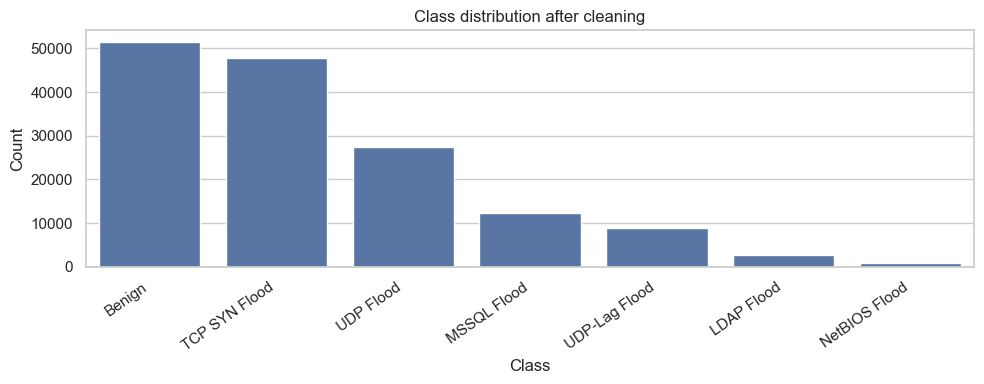

No missing values detected.


In [5]:
class_distribution = (
    combined_df[TARGET_COL]
    .value_counts()
    .rename_axis("class")
    .reset_index(name="count")
)
class_distribution["percent"] = (
    class_distribution["count"] / class_distribution["count"].sum() * 100
)
display(class_distribution)

binary_distribution = (
    combined_df[TARGET_COL]
    .map(lambda value: "Benign" if value == "Benign" else "Attack")
    .value_counts()
    .rename_axis("binary_class")
    .reset_index(name="count")
)
binary_distribution["percent"] = (
    binary_distribution["count"] / binary_distribution["count"].sum() * 100
)
display(binary_distribution)

plt.figure(figsize=(10, 4))
sns.barplot(data=class_distribution, x="class", y="count", color="#4c72b0")
plt.title("Class distribution after cleaning")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

missing_summary = (
    combined_df.isna().sum().loc[lambda s: s > 0].sort_values(ascending=False)
)
if missing_summary.empty:
    print("No missing values detected.")
else:
    display(missing_summary.rename("missing_count").to_frame().head(20))

,selected_numeric_feature
0,Fwd Header Length
1,Flow Bytes/s
2,Fwd Seg Size Min
3,Bwd Header Length
4,Fwd IAT Total
5,Flow Duration
6,Bwd IAT Total
7,Bwd IAT Max
8,Idle Max
9,Fwd IAT Max


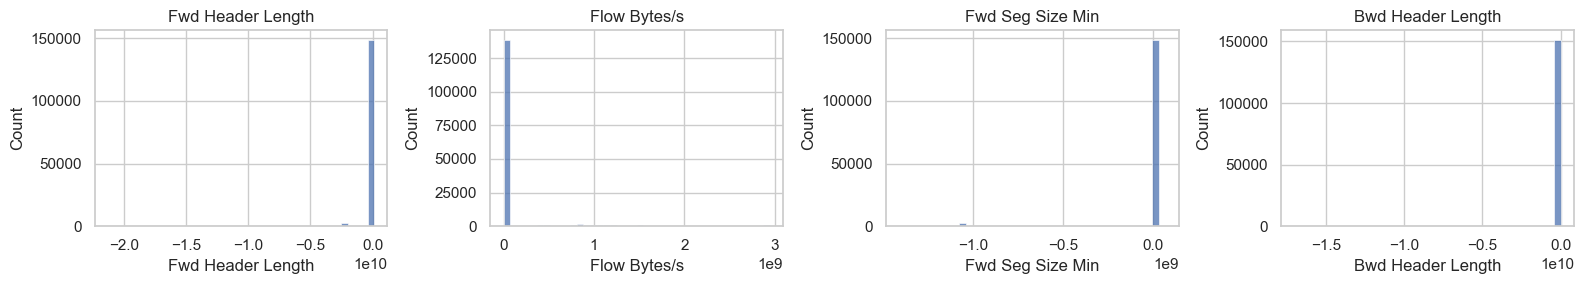

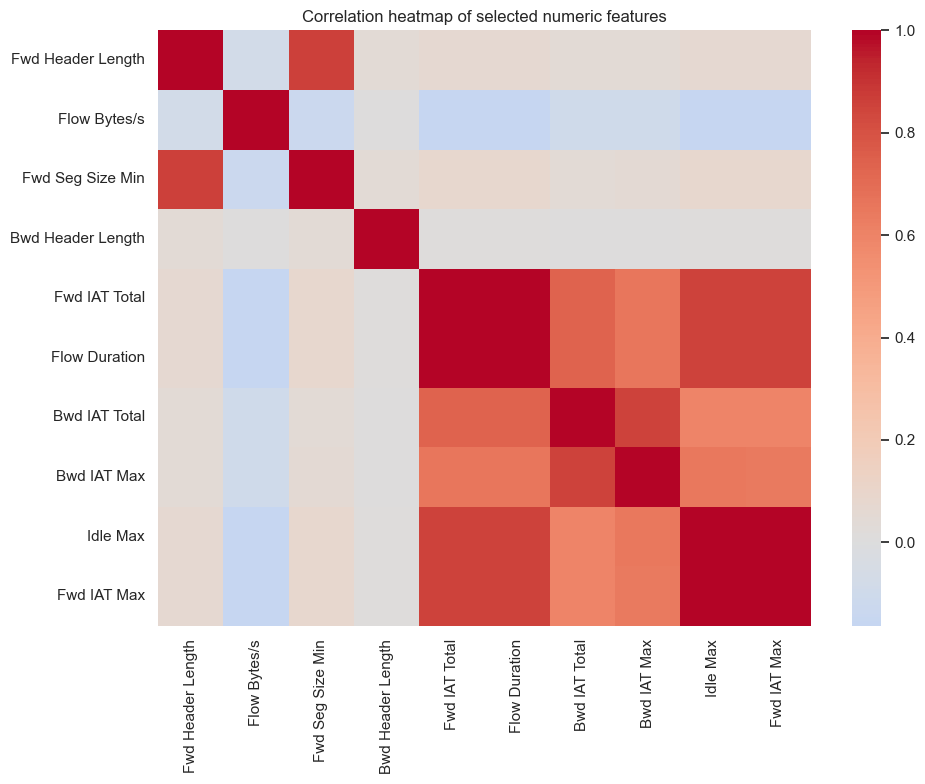

In [6]:
numeric_features = combined_df.select_dtypes(include=[np.number]).drop(columns=[TARGET_COL], errors="ignore")
if not numeric_features.empty:
    variance_top = numeric_features.var(numeric_only=True).sort_values(ascending=False).head(10).index.tolist()
    display(pd.DataFrame({"selected_numeric_feature": variance_top}))

    plot_cols = variance_top[:4]
    fig, axes = plt.subplots(1, len(plot_cols), figsize=(4 * len(plot_cols), 3))
    if len(plot_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, plot_cols):
        sns.histplot(combined_df[col].replace([np.inf, -np.inf], np.nan).dropna(), bins=40, ax=ax)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

    corr_cols = variance_top[:20]
    corr_matrix = (
        combined_df[corr_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(combined_df[corr_cols].median(numeric_only=True))
        .corr()
    )
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
    plt.title("Correlation heatmap of selected numeric features")
    plt.tight_layout()
    plt.show()
else:
    print("No numeric feature columns found for EDA plots.")

## 6. Data Quality and Leakage Check

In [7]:
def find_leakage_like_columns(columns):
    found = []
    for col in columns:
        normalized = re.sub(r"[_\-]+", " ", str(col).strip().lower())
        if any(re.search(pattern, normalized) for pattern in LEAKAGE_COLUMN_PATTERNS):
            found.append(col)
    return found


leakage_like_columns = [
    col for col in find_leakage_like_columns(combined_df.columns)
    if col != TARGET_COL
]
constant_columns = [
    col for col in combined_df.columns
    if col != TARGET_COL and combined_df[col].nunique(dropna=False) <= 1
]
high_unique_columns = [
    {
        "feature": col,
        "unique_count": int(combined_df[col].nunique(dropna=False)),
        "unique_ratio": float(combined_df[col].nunique(dropna=False) / len(combined_df)),
    }
    for col in combined_df.columns
    if col != TARGET_COL and combined_df[col].nunique(dropna=False) / len(combined_df) > 0.5
]

leakage_check = pd.DataFrame(
    [
        {"check": "Target is not in feature matrix", "status": "checked before split"},
        {"check": "Duplicate rows removed before split", "status": f"{combined_duplicates} removed after combine"},
        {"check": "Leakage-like columns detected", "status": ", ".join(map(str, leakage_like_columns)) or "none"},
        {"check": "Constant columns detected", "status": str(len(constant_columns))},
        {"check": "Preprocessing fit scope", "status": "inside Pipeline, fit on train/CV fold only"},
    ]
)
display(leakage_check)
display(pd.DataFrame(high_unique_columns).head(20))

,check,status
0,Target is not in feature matrix,checked before split
1,Duplicate rows removed before split,4014 removed after combine
2,Leakage-like columns detected,none
3,Constant columns detected,12
4,Preprocessing fit scope,"inside Pipeline, fit on train/CV fold only"


,feature,unique_count,unique_ratio
0,Flow Duration,88123,0.581532
1,Flow Bytes/s,96036,0.633750
2,Flow Packets/s,90102,0.594591
3,Flow IAT Mean,89992,0.593865
4,Flow IAT Std,101931,0.672652
5,Flow IAT Max,82221,0.542584
6,Fwd IAT Total,76469,0.504626
7,Fwd IAT Mean,77288,0.510031
8,Fwd IAT Std,86278,0.569356
9,Fwd Packets/s,89115,0.588078


## 7. Preprocessing and Stratified Split

In [8]:
X_all = combined_df.drop(columns=[TARGET_COL])
y_text = combined_df[TARGET_COL].astype(str)

X_train, X_test, y_train_text, y_test_text = train_test_split(
    X_all,
    y_text,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_text,
)

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train_text)
y_test = label_encoder.transform(y_test_text)
class_names = label_encoder.classes_.tolist()

label_mapping = pd.DataFrame(
    {"encoded_label": range(len(class_names)), "original_label": class_names}
)
display(label_mapping)

split_distribution = pd.DataFrame(
    {
        "original": y_text.value_counts().sort_index(),
        "train": y_train_text.value_counts().sort_index(),
        "test": y_test_text.value_counts().sort_index(),
    }
)
split_distribution["train_plus_test"] = split_distribution["train"] + split_distribution["test"]
split_distribution["integrity_ok"] = split_distribution["original"] == split_distribution["train_plus_test"]
display(split_distribution)

if not split_distribution["integrity_ok"].all():
    raise ValueError("Split integrity check failed: train + test counts do not match original counts.")

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Target included in X:", TARGET_COL in X_train.columns)

,encoded_label,original_label
0,0,Benign
1,1,LDAP Flood
2,2,MSSQL Flood
3,3,NetBIOS Flood
4,4,TCP SYN Flood
5,5,UDP Flood
6,6,UDP-Lag Flood


,original,train,test,train_plus_test,integrity_ok
Label,,,,,
Benign,51534,41227,10307,51534,True
LDAP Flood,2722,2178,544,2722,True
MSSQL Flood,12228,9782,2446,12228,True
NetBIOS Flood,833,666,167,833,True
TCP SYN Flood,47779,38223,9556,47779,True
UDP Flood,27525,22020,5505,27525,True
UDP-Lag Flood,8915,7132,1783,8915,True


X_train: (121228, 77) X_test: (30308, 77)
Target included in X: False


## 8. Imbalance Handling

In [9]:
train_class_counts = pd.Series(y_train).value_counts().sort_index()
train_class_counts.index = [class_names[idx] for idx in train_class_counts.index]
test_class_counts = pd.Series(y_test).value_counts().sort_index()
test_class_counts.index = [class_names[idx] for idx in test_class_counts.index]

imbalance_table = pd.DataFrame(
    {
        "train_count": train_class_counts,
        "test_count": test_class_counts,
    }
)
imbalance_table["train_percent"] = imbalance_table["train_count"] / imbalance_table["train_count"].sum() * 100
imbalance_table["test_percent"] = imbalance_table["test_count"] / imbalance_table["test_count"].sum() * 100
display(imbalance_table)

minority_class_indices = [
    int(label)
    for label, count in pd.Series(y_train).value_counts().items()
    if count < 1000
]
if not minority_class_indices:
    minority_class_indices = [int(pd.Series(y_train).value_counts().idxmin())]
minority_class_names = [class_names[idx] for idx in minority_class_indices]
print("Minority classes used for recall tracking:", minority_class_names)

rare_warning = imbalance_table[imbalance_table["train_count"] < 100]
if not rare_warning.empty:
    print("Warning: Some classes have very few training samples and may be unstable:")
    display(rare_warning)

max_oversample_target = 2000
oversample_strategy = {
    int(label): int(min(max_oversample_target, max(count, count * 4)))
    for label, count in pd.Series(y_train).value_counts().sort_index().items()
    if count < max_oversample_target
}
print("RandomOverSampler strategy:", oversample_strategy)
print("RandomUnderSampler cap per majority class: 8000")

,train_count,test_count,train_percent,test_percent
Benign,41227,10307,34.007820,34.007523
LDAP Flood,2178,544,1.796615,1.794906
MSSQL Flood,9782,2446,8.069093,8.070476
NetBIOS Flood,666,167,0.549378,0.551010
TCP SYN Flood,38223,9556,31.529845,31.529629
UDP Flood,22020,5505,18.164121,18.163521
UDP-Lag Flood,7132,1783,5.883129,5.882935


Minority classes used for recall tracking: ['NetBIOS Flood']
RandomOverSampler strategy: {3: 2000}
RandomUnderSampler cap per majority class: 8000


## 9. Model Training

In [10]:
def make_preprocessor():
    return TrafficFeaturePreprocessor(correlation_threshold=0.90)


def make_pipeline(estimator, sampler=None):
    steps = [("preprocess", make_preprocessor())]
    if sampler is not None:
        steps.append(("sampler", sampler))
    steps.append(("model", estimator))
    return ImbPipeline(steps)


def random_forest(class_weight=None):
    return RandomForestClassifier(
        n_estimators=80,
        max_depth=8,
        min_samples_split=200,
        min_samples_leaf=80,
        max_features="sqrt",
        max_samples=0.70,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def xgboost_model():
    return XGBClassifier(
        objective="multi:softprob",
        num_class=len(class_names),
        eval_metric="mlogloss",
        n_estimators=120,
        learning_rate=0.06,
        max_depth=2,
        min_child_weight=25,
        subsample=0.65,
        colsample_bytree=0.65,
        reg_alpha=0.5,
        reg_lambda=12.0,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def mlp_model():
    return MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        alpha=0.01,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.15,
        max_iter=120,
        random_state=RANDOM_STATE,
    )


candidate_specs = [
    {
        "model": "Random Forest",
        "method": "baseline",
        "pipeline": make_pipeline(random_forest()),
    },
    {
        "model": "Random Forest",
        "method": "class_weight",
        "pipeline": make_pipeline(random_forest(class_weight="balanced_subsample")),
    },
    {
        "model": "XGBoost",
        "method": "baseline",
        "pipeline": make_pipeline(xgboost_model()),
    },
    {
        "model": "XGBoost",
        "method": "RandomUnderSampler",
        "pipeline": make_pipeline(
            xgboost_model(),
            RandomUnderSampler(
                sampling_strategy=CappedUnderSamplingStrategy(cap=8000),
                random_state=RANDOM_STATE,
            ),
        ),
    },
    {
        "model": "MLP Classifier",
        "method": "RandomOverSampler",
        "pipeline": make_pipeline(
            mlp_model(),
            RandomOverSampler(
                sampling_strategy=oversample_strategy,
                random_state=RANDOM_STATE,
            ),
        ),
    },
]

print("Candidate models:", len(candidate_specs))
display(pd.DataFrame([{k: v for k, v in spec.items() if k != "pipeline"} for spec in candidate_specs]))

Candidate models: 5


,model,method
0,Random Forest,baseline
1,Random Forest,class_weight
2,XGBoost,baseline
3,XGBoost,RandomUnderSampler
4,MLP Classifier,RandomOverSampler


In [11]:
def make_cv_sample(X, y, max_per_class=CV_MAX_PER_CLASS):
    y_series = pd.Series(y, index=X.index)
    sampled_indices = []
    for label, label_indices in y_series.groupby(y_series).groups.items():
        label_indices = list(label_indices)
        if len(label_indices) > max_per_class:
            sampled = pd.Series(label_indices).sample(
                n=max_per_class,
                random_state=RANDOM_STATE,
            ).tolist()
        else:
            sampled = label_indices
        sampled_indices.extend(sampled)
    sampled_indices = pd.Index(sampled_indices)
    return X.loc[sampled_indices], y_series.loc[sampled_indices].to_numpy()


def minority_recall_score(y_true, y_pred):
    return recall_score(
        y_true,
        y_pred,
        labels=minority_class_indices,
        average="macro",
        zero_division=0,
    )


def evaluate_candidate(spec, X_train, y_train, X_test, y_test):
    pipeline = clone(spec["pipeline"])
    start = time.time()
    pipeline.fit(X_train, y_train)
    fit_seconds = time.time() - start

    y_train_pred = pipeline.predict(X_train)
    y_test_pred = pipeline.predict(X_test)
    report = classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    row = {
        "Model": spec["model"],
        "Imbalance Method": spec["method"],
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_test_pred),
        "Macro F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_test, y_test_pred, average="weighted", zero_division=0),
        "Minority Class Recall": minority_recall_score(y_test, y_test_pred),
        "Train Macro F1": f1_score(y_train, y_train_pred, average="macro", zero_division=0),
        "Test Macro F1": f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Train/Test Gap": f1_score(y_train, y_train_pred, average="macro", zero_division=0)
        - f1_score(y_test, y_test_pred, average="macro", zero_division=0),
        "Fit Seconds": fit_seconds,
    }

    for class_name in class_names:
        row[f"{class_name} Recall"] = report.get(class_name, {}).get("recall", 0.0)
        row[f"{class_name} F1"] = report.get(class_name, {}).get("f1-score", 0.0)

    tcp_syn_f1 = row.get("TCP SYN Flood F1", np.nan)
    udp_lag_f1 = row.get("UDP-Lag Flood F1", np.nan)
    notes = []
    if not np.isnan(tcp_syn_f1) and tcp_syn_f1 < 0.50:
        notes.append("TCP SYN F1 low")
    if not np.isnan(udp_lag_f1) and udp_lag_f1 < 0.20:
        notes.append("UDP-Lag F1 low")
    row["Notes"] = "; ".join(notes) if notes else "OK"
    return pipeline, row, y_test_pred, report


X_cv, y_cv = make_cv_sample(X_train, y_train)
print("CV sample shape:", X_cv.shape)

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_scoring = {
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
    "balanced_accuracy": "balanced_accuracy",
    "minority_recall": make_scorer(minority_recall_score),
}

fitted_models = {}
predictions = {}
reports = {}
comparison_rows = []

for spec in candidate_specs:
    print(f"Training {spec['model']} | {spec['method']} ...")
    cv_result = cross_validate(
        clone(spec["pipeline"]),
        X_cv,
        y_cv,
        cv=cv,
        scoring=cv_scoring,
        n_jobs=1,
        error_score="raise",
    )
    fitted_pipeline, row, y_pred, report = evaluate_candidate(
        spec,
        X_train,
        y_train,
        X_test,
        y_test,
    )
    row["CV Macro F1 Mean"] = cv_result["test_macro_f1"].mean()
    row["CV Macro F1 Std"] = cv_result["test_macro_f1"].std()
    row["CV Weighted F1 Mean"] = cv_result["test_weighted_f1"].mean()
    row["CV Balanced Accuracy Mean"] = cv_result["test_balanced_accuracy"].mean()
    row["CV Minority Recall Mean"] = cv_result["test_minority_recall"].mean()

    model_key = f"{spec['model']} | {spec['method']}"
    fitted_models[model_key] = fitted_pipeline
    predictions[model_key] = y_pred
    reports[model_key] = report
    comparison_rows.append(row)

comparison_df = pd.DataFrame(comparison_rows)

guardrail_penalty = (
    comparison_df["Notes"].str.contains("TCP SYN F1 low", regex=False).astype(float) * 0.50
    + comparison_df["Notes"].str.contains("UDP-Lag F1 low", regex=False).astype(float) * 0.40
)
comparison_df["Selection Score"] = (
    comparison_df["Macro F1"]
    + 0.50 * comparison_df["Minority Class Recall"]
    + 0.25 * comparison_df["Balanced Accuracy"]
    - 0.25 * comparison_df["Train/Test Gap"].clip(lower=0)
    - guardrail_penalty
)

main_columns = [
    "Model",
    "Imbalance Method",
    "Accuracy",
    "Balanced Accuracy",
    "Macro F1",
    "Weighted F1",
    "Minority Class Recall",
    "Train Macro F1",
    "Test Macro F1",
    "Train/Test Gap",
    "CV Macro F1 Mean",
    "CV Macro F1 Std",
    "TCP SYN Flood F1",
    "UDP-Lag Flood F1",
    "Notes",
    "Selection Score",
    "Fit Seconds",
]
display(comparison_df[main_columns].sort_values("Selection Score", ascending=False))

CV sample shape: (17844, 77)
Training Random Forest | baseline ...


Training Random Forest | class_weight ...


Training XGBoost | baseline ...


Training XGBoost | RandomUnderSampler ...


Training MLP Classifier | RandomOverSampler ...


C:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (120) reached and the optimization hasn't converged yet.
  warnings.warn(


C:\Users\ACER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (120) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Imbalance Method,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Minority Class Recall,Train Macro F1,Test Macro F1,Train/Test Gap,CV Macro F1 Mean,CV Macro F1 Std,TCP SYN Flood F1,UDP-Lag Flood F1,Notes,Selection Score,Fit Seconds
2,XGBoost,baseline,0.971955,0.906242,0.921261,0.971268,0.760479,0.917769,0.921261,-0.003492,0.912537,0.002511,0.992941,0.842866,OK,1.528061,31.172889
3,XGBoost,RandomUnderSampler,0.967863,0.906172,0.915888,0.967351,0.766467,0.914071,0.915888,-0.001817,0.912111,0.001795,0.989428,0.817905,OK,1.525664,12.074584
4,MLP Classifier,RandomOverSampler,0.961759,0.889729,0.902832,0.959977,0.790419,0.899385,0.902832,-0.003447,0.873623,0.010326,0.979639,0.753719,OK,1.520474,86.361739
1,Random Forest,class_weight,0.963805,0.912642,0.888281,0.963834,0.790419,0.882647,0.888281,-0.005634,0.902548,0.002496,0.989535,0.816450,OK,1.511651,7.412768
0,Random Forest,baseline,0.970602,0.888635,0.912696,0.969813,0.670659,0.911962,0.912696,-0.000734,0.896590,0.005455,0.992304,0.840125,OK,1.470184,6.957942


## 10. Evaluation of the Best Model

Best model: XGBoost | baseline
Model                      XGBoost
Imbalance Method          baseline
Accuracy                  0.971955
Balanced Accuracy         0.906242
Macro F1                  0.921261
Weighted F1               0.971268
Minority Class Recall     0.760479
Train Macro F1            0.917769
Test Macro F1             0.921261
Train/Test Gap           -0.003492
CV Macro F1 Mean          0.912537
CV Macro F1 Std           0.002511
TCP SYN Flood F1          0.992941
UDP-Lag Flood F1          0.842866
Notes                           OK
Selection Score           1.528061
Fit Seconds              31.172889


,precision,recall,f1-score,support
Benign,0.992961,0.999127,0.996034,10307.000000
LDAP Flood,0.870968,0.893382,0.882033,544.000000
MSSQL Flood,0.924756,0.969747,0.946717,2446.000000
NetBIOS Flood,0.927007,0.760479,0.835526,167.000000
TCP SYN Flood,0.999682,0.986291,0.992941,9556.000000
UDP Flood,0.924615,0.982561,0.952708,5505.000000
UDP-Lag Flood,0.958542,0.752103,0.842866,1783.000000
accuracy,0.971955,0.971955,0.971955,0.971955
macro avg,0.942647,0.906242,0.921261,30308.000000
weighted avg,0.972584,0.971955,0.971268,30308.000000


,Benign,LDAP Flood,MSSQL Flood,NetBIOS Flood,TCP SYN Flood,UDP Flood,UDP-Lag Flood
Benign,10298,0,1,8,0,0,0
LDAP Flood,4,486,54,0,0,0,0
MSSQL Flood,1,57,2372,0,0,16,0
NetBIOS Flood,4,1,30,127,0,2,3
TCP SYN Flood,58,0,12,0,9425,6,55
UDP Flood,1,0,92,2,1,5409,0
UDP-Lag Flood,5,14,4,0,2,417,1341


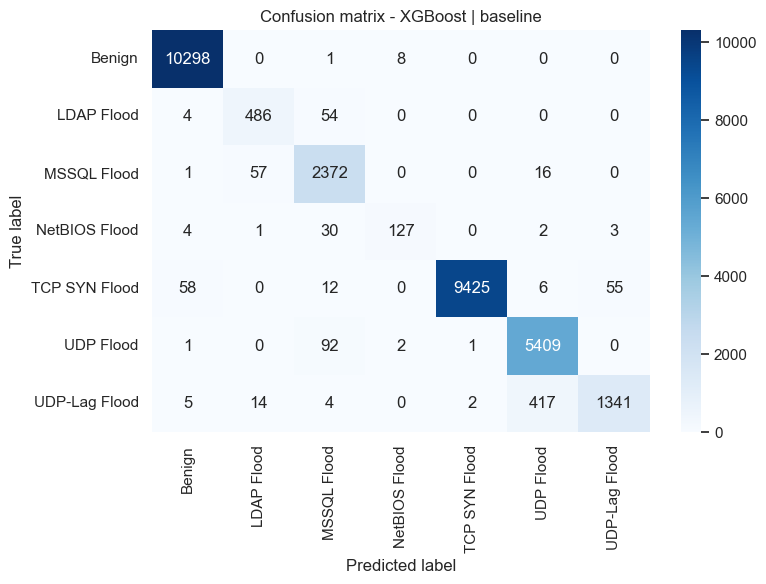

,predicted_count
Benign,10371
LDAP Flood,558
MSSQL Flood,2565
NetBIOS Flood,137
TCP SYN Flood,9428
UDP Flood,5850
UDP-Lag Flood,1399


In [12]:
best_row = comparison_df.sort_values("Selection Score", ascending=False).iloc[0]
best_model_key = f"{best_row['Model']} | {best_row['Imbalance Method']}"
best_model = fitted_models[best_model_key]
y_pred_best = predictions[best_model_key]
best_report = reports[best_model_key]

print("Best model:", best_model_key)
print(best_row[main_columns].to_string())

report_df = pd.DataFrame(best_report).transpose()
display(report_df)

cm = confusion_matrix(y_test, y_pred_best, labels=list(range(len(class_names))))
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
display(cm_df)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion matrix - {best_model_key}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

y_pred_counts = pd.Series(y_pred_best).value_counts().sort_index()
y_pred_counts.index = [class_names[idx] for idx in y_pred_counts.index]
display(y_pred_counts.rename("predicted_count").to_frame())

if best_row["Test Macro F1"] > 0.98:
    print("Warning: Test Macro F1 is very high. The dataset may be easy or hidden leakage may still exist.")
if best_row["Train/Test Gap"] > 0.05:
    print("Warning: Train/Test Macro F1 gap is large, indicating overfitting risk.")
if best_row["Notes"] != "OK":
    print("Warning:", best_row["Notes"])

## 11. Model Comparison

,Model,Imbalance Method,Accuracy,Balanced Accuracy,Macro F1,Weighted F1,Minority Class Recall,Train Macro F1,Test Macro F1,Train/Test Gap,CV Macro F1 Mean,CV Macro F1 Std,TCP SYN Flood F1,UDP-Lag Flood F1,Notes,Selection Score,Fit Seconds
2,XGBoost,baseline,0.971955,0.906242,0.921261,0.971268,0.760479,0.917769,0.921261,-0.003492,0.912537,0.002511,0.992941,0.842866,OK,1.528061,31.172889
3,XGBoost,RandomUnderSampler,0.967863,0.906172,0.915888,0.967351,0.766467,0.914071,0.915888,-0.001817,0.912111,0.001795,0.989428,0.817905,OK,1.525664,12.074584
4,MLP Classifier,RandomOverSampler,0.961759,0.889729,0.902832,0.959977,0.790419,0.899385,0.902832,-0.003447,0.873623,0.010326,0.979639,0.753719,OK,1.520474,86.361739
1,Random Forest,class_weight,0.963805,0.912642,0.888281,0.963834,0.790419,0.882647,0.888281,-0.005634,0.902548,0.002496,0.989535,0.816450,OK,1.511651,7.412768
0,Random Forest,baseline,0.970602,0.888635,0.912696,0.969813,0.670659,0.911962,0.912696,-0.000734,0.896590,0.005455,0.992304,0.840125,OK,1.470184,6.957942


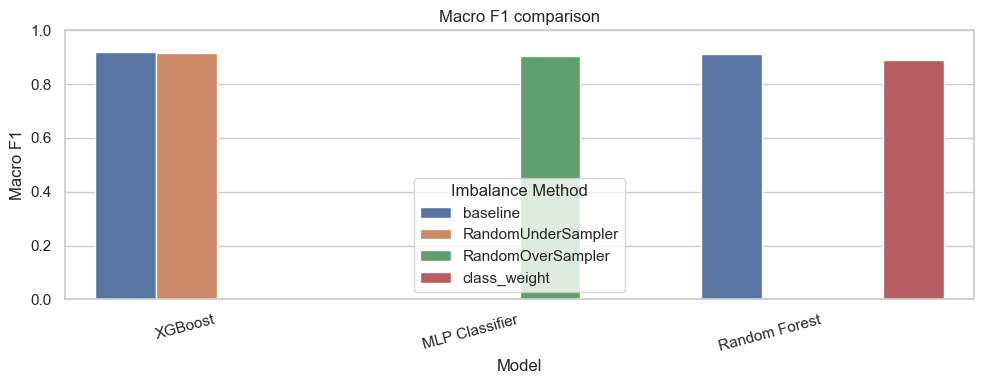

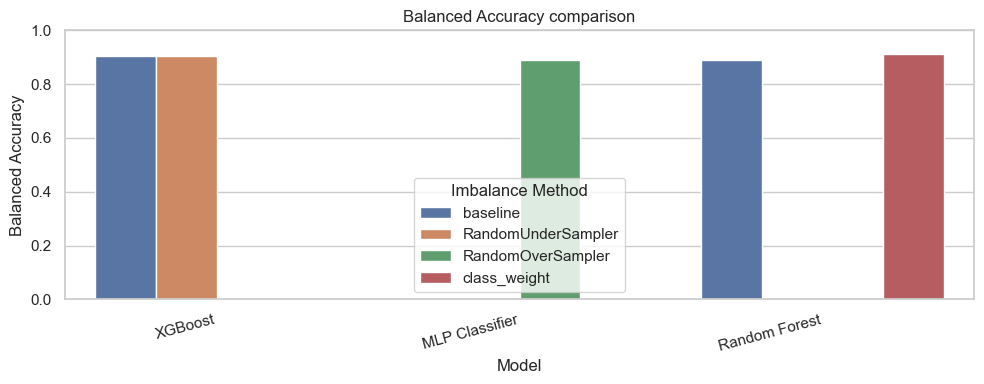

In [13]:
comparison_plot_df = comparison_df.sort_values("Selection Score", ascending=False).copy()
display(comparison_plot_df[main_columns])

plt.figure(figsize=(10, 4))
sns.barplot(
    data=comparison_plot_df,
    x="Model",
    y="Macro F1",
    hue="Imbalance Method",
)
plt.title("Macro F1 comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(
    data=comparison_plot_df,
    x="Model",
    y="Balanced Accuracy",
    hue="Imbalance Method",
)
plt.title("Balanced Accuracy comparison")
plt.ylim(0, 1)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

## 12. Save Results

In [14]:
comparison_path = RESULTS_DIR / "report_ready_model_comparison.csv"
report_path = RESULTS_DIR / "report_ready_classification_report.csv"
cm_path = RESULTS_DIR / "report_ready_confusion_matrix.csv"
summary_path = RESULTS_DIR / "report_ready_final_summary.csv"
model_path = MODELS_DIR / "report_ready_best_model.pkl"
selected_model_path = MODELS_DIR / "selected_model.pkl"
metadata_path = RESULTS_DIR / "report_ready_selected_model_metadata.csv"

comparison_df.to_csv(comparison_path, index=False)
report_df.to_csv(report_path)
cm_df.to_csv(cm_path)

final_summary = pd.DataFrame(
    [
        {
            "total_rows": len(combined_df),
            "total_features_before_preprocessing": X_all.shape[1],
            "duplicates_removed_after_combine": combined_duplicates,
            "missing_values": missing_count,
            "inf_values": inf_count,
            "best_model": best_model_key,
            "accuracy": best_row["Accuracy"],
            "balanced_accuracy": best_row["Balanced Accuracy"],
            "macro_f1": best_row["Macro F1"],
            "weighted_f1": best_row["Weighted F1"],
            "minority_recall": best_row["Minority Class Recall"],
            "train_test_gap": best_row["Train/Test Gap"],
            "cv_macro_f1_mean": best_row["CV Macro F1 Mean"],
            "cv_macro_f1_std": best_row["CV Macro F1 Std"],
            "notes": best_row["Notes"],
        }
    ]
)
final_summary.to_csv(summary_path, index=False)
display(final_summary)

# Ryu/SDN controller expects the pickle object itself to expose
# predict_proba(features). Therefore selected_model.pkl stores the
# fitted Pipeline directly, not a metadata dictionary.
with open(model_path, "wb") as file:
    pickle.dump(best_model, file)
with open(selected_model_path, "wb") as file:
    pickle.dump(best_model, file)

selected_metadata = pd.DataFrame(
    [
        {
            "selected_model_file": str(selected_model_path),
            "best_model": best_model_key,
            "class_names": "|".join(class_names),
            "accuracy": best_row["Accuracy"],
            "balanced_accuracy": best_row["Balanced Accuracy"],
            "macro_f1": best_row["Macro F1"],
            "weighted_f1": best_row["Weighted F1"],
            "minority_recall": best_row["Minority Class Recall"],
            "cv_macro_f1_mean": best_row["CV Macro F1 Mean"],
            "cv_macro_f1_std": best_row["CV Macro F1 Std"],
        }
    ]
)
selected_metadata.to_csv(metadata_path, index=False)

print("Saved comparison:", comparison_path)
print("Saved classification report:", report_path)
print("Saved confusion matrix:", cm_path)
print("Saved summary:", summary_path)
print("Saved best model:", model_path)
print("Saved SDN selected model:", selected_model_path)
print("Saved selected model metadata:", metadata_path)

,total_rows,total_features_before_preprocessing,duplicates_removed_after_combine,missing_values,inf_values,best_model,accuracy,balanced_accuracy,macro_f1,weighted_f1,minority_recall,train_test_gap,cv_macro_f1_mean,cv_macro_f1_std,notes
0,151536,77,4014,0,0,XGBoost | baseline,0.971955,0.906242,0.921261,0.971268,0.760479,-0.003492,0.912537,0.002511,OK


Saved comparison: D:\source\CyRadar\VBoxShare\mlddos\results\report_ready_model_comparison.csv
Saved classification report: D:\source\CyRadar\VBoxShare\mlddos\results\report_ready_classification_report.csv
Saved confusion matrix: D:\source\CyRadar\VBoxShare\mlddos\results\report_ready_confusion_matrix.csv
Saved summary: D:\source\CyRadar\VBoxShare\mlddos\results\report_ready_final_summary.csv
Saved best model: D:\source\CyRadar\VBoxShare\mlddos\saved_models\report_ready_best_model.pkl
Saved SDN selected model: D:\source\CyRadar\VBoxShare\mlddos\saved_models\selected_model.pkl
Saved selected model metadata: D:\source\CyRadar\VBoxShare\mlddos\results\report_ready_selected_model_metadata.csv


## 13. SDN Controller Compatibility Check

In [15]:
with open(selected_model_path, "rb") as file:
    sdn_model = pickle.load(file)

sdn_sample = pd.DataFrame([{column: 0.0 for column in CICDDOS_FEATURE_COLUMNS}])
sdn_sample["Protocol"] = 6
sdn_sample["Flow Duration"] = 1_000_000
sdn_sample["Total Fwd Packets"] = 10
sdn_sample["Fwd Packets Length Total"] = 600
sdn_sample["Flow Packets/s"] = 10
sdn_sample["Flow Bytes/s"] = 600

proba = sdn_model.predict_proba(sdn_sample)[0]
pred_index = int(np.argmax(proba))
sdn_check = pd.DataFrame(
    [
        {
            "selected_model_path": str(selected_model_path),
            "predict_proba_ok": True,
            "predicted_index": pred_index,
            "predicted_label": class_names[pred_index],
            "confidence": float(proba[pred_index]),
            "input_feature_count": sdn_sample.shape[1],
        }
    ]
)
display(sdn_check)

,selected_model_path,predict_proba_ok,predicted_index,predicted_label,confidence,input_feature_count
0,D:\source\CyRadar\VBoxShare\mlddos\saved_model...,True,0,Benign,0.787565,77


## 14. Final Conclusion

In [16]:
conclusion = f'''
Best model: {best_model_key}
Accuracy: {best_row['Accuracy']:.4f}
Balanced Accuracy: {best_row['Balanced Accuracy']:.4f}
Macro F1: {best_row['Macro F1']:.4f}
Weighted F1: {best_row['Weighted F1']:.4f}
Minority Recall: {best_row['Minority Class Recall']:.4f}
Train/Test Macro F1 Gap: {best_row['Train/Test Gap']:.4f}
CV Macro F1: {best_row['CV Macro F1 Mean']:.4f} +/- {best_row['CV Macro F1 Std']:.4f}

Nhận xét: mô hình được chọn không chỉ dựa trên Accuracy mà còn xét Macro F1,
Balanced Accuracy, recall của nhóm lớp ít mẫu và cảnh báo nếu một lớp quan trọng
bị dự đoán kém. Với các lớp rất ít mẫu như UDP-Lag Flood, kết quả có thể chưa
ổn định và cần thêm dữ liệu thực tế để cải thiện khả năng tổng quát hóa.
'''
print(conclusion)


Best model: XGBoost | baseline
Accuracy: 0.9720
Balanced Accuracy: 0.9062
Macro F1: 0.9213
Weighted F1: 0.9713
Minority Recall: 0.7605
Train/Test Macro F1 Gap: -0.0035
CV Macro F1: 0.9125 +/- 0.0025

Nhận xét: mô hình được chọn không chỉ dựa trên Accuracy mà còn xét Macro F1,
Balanced Accuracy, recall của nhóm lớp ít mẫu và cảnh báo nếu một lớp quan trọng
bị dự đoán kém. Với các lớp rất ít mẫu như UDP-Lag Flood, kết quả có thể chưa
ổn định và cần thêm dữ liệu thực tế để cải thiện khả năng tổng quát hóa.

